# A graph engine inside Vertica

**Graph analytics on one billion rows, side by side with Neo4j.**
Code: https://github.com/mogomo/vertica-graph-udx (MIT). Earlier work: https://github.com/mogomo/vertica-graphs-and-trees.

## Abstract

`vgraph` is an open-source C++ extension (a UDx) that adds graph functions to the Vertica analytic database:
neighbourhoods within k hops, shortest paths, connected components and PageRank. The edges stay in an ordinary
table, and every function is called from SQL.

We ran the same questions, on the same data, on the same machine, in Vertica and in Neo4j, at **100 million**
rows and again at **1 billion** rows. Both systems returned the same answers everywhere they could answer.

On a billion rows Vertica finds everyone within 9 hops of David, 7.3 million people, in **0.08 s**, against
Neo4j's 5.25 s: **69 times faster**. It is **13 times** faster at PageRank, **5 times** at the shortest path
and **3 times** at connected components, before counting the 169 s in-memory projection Neo4j has to build first, and it uses **less than
half the disk**. The smallest questions cost what a SQL statement costs in both systems.

The result that matters most is not a ratio. Neo4j's store for the billion-row graph is **26 GB** on a 34 GB
machine, and no single configuration could answer every question: the traversals need a large page cache, the
whole-graph algorithms need a large heap, and the two do not fit together. Vertica's index for the same graph
is **6.7 GB**, so one configuration answers everything.

| Section | Content |
|---|---|
| 1 | Background: graph databases, Vertica, and what a UDx is |
| 2 | The story: one customer question, two repositories |
| 3 | The test environment |
| 4 | The sample data: David and his contacts |
| 5 | The files involved in the tests |
| 6 | The functions, live |
| 7 | Results: 100 million rows, Neo4j and Vertica side by side |
| 8 | Results: one billion rows, Neo4j and Vertica side by side |
| 9 | Bottom line |

**To run this notebook:** a Vertica database with `vgraph` installed (`make deploy`), and Python with
`vertica-python`, `networkx`, `matplotlib`, `pandas`. The connection is read from the environment variables
`VSQL_HOST`, `VSQL_PORT`, `VSQL_USER`, `VSQL_PASSWORD`, `VSQL_DATABASE`, the same ones the repository's scripts
use. Nothing is stored in the notebook.

In [1]:
import os, math, time, warnings
import pandas as pd, networkx as nx, matplotlib.pyplot as plt, matplotlib as mpl
import vertica_python
warnings.filterwarnings("ignore")

conn = vertica_python.connect(
    host=os.environ.get("VSQL_HOST", "127.0.0.1"), port=int(os.environ.get("VSQL_PORT", 5433)),
    user=os.environ.get("VSQL_USER", "dbadmin"), password=os.environ.get("VSQL_PASSWORD", ""),
    database=os.environ.get("VSQL_DATABASE", ""), autocommit=True)

def run(sql):
    # statements without a result
    cur = conn.cursor()
    for stmt in [s for s in sql.split(";\n") if s.strip()]:
        cur.execute(stmt)
        while cur.nextset(): pass

def q(sql):
    # a query into a pandas DataFrame; q.ms = the server time of the statement, from Vertica's own system table
    cur = conn.cursor(); cur.execute(sql); rows = cur.fetchall()
    frame = pd.DataFrame(rows, columns=[c.name for c in cur.description])
    cur.execute("SELECT request_duration_ms FROM v_monitor.query_requests WHERE session_id = CURRENT_SESSION() "
                "AND request NOT ILIKE '%v_monitor.query_requests%' ORDER BY start_timestamp DESC LIMIT 1")
    q.ms = cur.fetchall()[0][0]
    return frame

def human(ms): return f"{ms / 1000:.1f} s" if ms >= 1000 else f"{ms:.0f} ms"

# one look for every chart. Colour follows the system: Vertica is blue, Neo4j is orange.
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e6e5e0", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RINGS = ["#d03b3b", "#0d366b", "#2a78d6", "#9ec5f4"]          # David, then 1, 2 and 3 hops away
mpl.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 130, "font.size": 10, "text.color": INK, "axes.labelcolor": INK2, "axes.edgecolor": GRID,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left"})
print(q("SELECT vgraph.gversion() OVER()").T)

                                                 0
library_version                              0.1.0
format_version                                   1
build_flags      -O2 -std=c++17 aarch64 g++-11.5.0


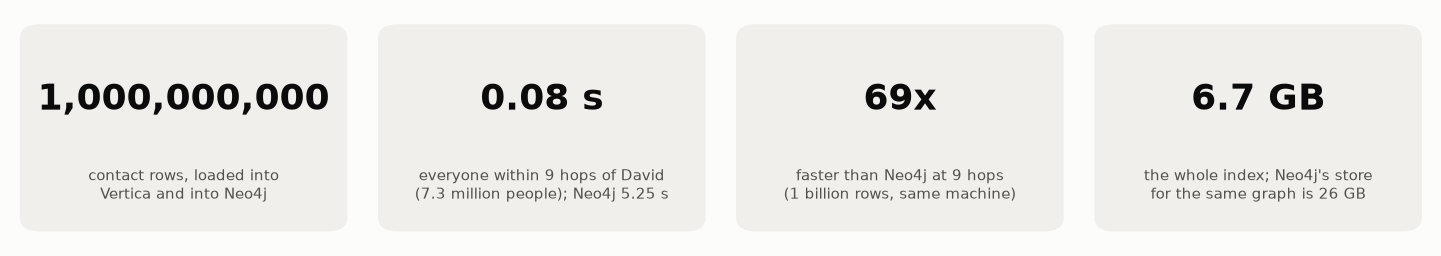

In [2]:
# the headline numbers (measured; sections 7 and 8)
fig, axes = plt.subplots(1, 4, figsize=(11, 2.3), gridspec_kw={"wspace": 0.05, "left": 0.005, "right": 0.995})
tiles = [("1,000,000,000", "contact rows, loaded into\nVertica and into Neo4j"), ("0.08 s", "everyone within 9 hops of David\n(7.3 million people); Neo4j 5.25 s"),
         ("69x", "faster than Neo4j at 9 hops\n(1 billion rows, same machine)"), ("6.7 GB", "the whole index; Neo4j's store\nfor the same graph is 26 GB")]
for ax, (big, small) in zip(axes, tiles):
    ax.set_axis_off(); ax.grid(False)
    ax.add_patch(mpl.patches.FancyBboxPatch((0.02, 0.05), 0.96, 0.9, boxstyle="round,pad=0,rounding_size=0.06", fc="#f0efec", ec="none", transform=ax.transAxes))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.text(0.5, 0.62, big, ha="center", va="center", fontsize=20, fontweight="bold", color=INK, transform=ax.transAxes)
    ax.text(0.5, 0.25, small, ha="center", va="center", fontsize=8.5, color=INK2, transform=ax.transAxes)
plt.show()

## 1. Background

**A graph** is a set of things (nodes) and the connections between them (edges): people and their contacts,
accounts and transfers, parts and assemblies. Most graph questions are traversals: start at one node and follow
the edges, level by level. "Friends of friends" is a traversal of two levels.

**A graph database**, such as Neo4j, is built for that. Every node record points directly at its edges, so
following an edge is following a pointer. Questions are written in Cypher. The price: the graph lives in a
second system, as a copy of data that usually comes from somewhere else, and whole-graph algorithms (PageRank,
components) first need a projection of the graph into memory.

**A relational analytic database**, such as Vertica, stores tables by column, sorted and compressed, spread over
the nodes of a cluster. It scans, joins and aggregates billions of rows and runs machine learning in the
database. A contact table fits well: two integer columns. But in plain SQL every level of a traversal is a join
against the whole table, so deep questions take seconds.

**A UDx** (user-defined extension) closes that gap. It is a function written in C++ against the Vertica SDK and
compiled into a library. After `CREATE LIBRARY` and `CREATE FUNCTION` it is part of the Vertica engine:
**anybody can call it from SQL like a built-in function**, in a query, a view, a join or a BI tool. Vertica
handles the parallel plan, the security, the resource management and, in fenced mode, the isolation in a
separate process. A UDx is also simple to write and maintain: one class that reads rows and writes rows, and one
factory that declares the argument and return types. In this repository every function is one small file in
`src/udx`; the graph algorithms are plain C++ without any Vertica code, tested on a laptop.

## 2. The story: one customer question, two repositories

A customer asked me: *"Can Vertica give me level 9 of David's contacts, the way Neo4j does?"*

**The first repository**, [vertica-graphs-and-trees](https://github.com/mogomo/vertica-graphs-and-trees), was my
answer in plain SQL: a stored procedure that runs one `INSERT ... SELECT` per level. It answers level 9 on
100 million rows in a few seconds. It worked, but it ended with an honest sentence: for algorithms such as
PageRank, "a graph engine remains the right tool".

That sentence was the trigger for **the second repository**,
[vertica-graph-udx](https://github.com/mogomo/vertica-graph-udx): the graph engine itself, written as a UDx,
inside Vertica.

Then I installed Neo4j on the same machine, loaded the same data and asked the same questions. I expected to
write "close enough, and simpler to operate". **The surprise: Vertica with the UDx was faster.**

## 3. The test environment

| | |
|---|---|
| Machine | one virtual machine on a Mac laptop: ARM (aarch64), 8 cores, 35 GB RAM, Rocky Linux 9 |
| Vertica | 26.2, one node; `vgraph` installed unfenced, 8 threads (one per core) |
| Neo4j | 5.26 Community, APOC, Graph Data Science 2.13.4, JDK 21; loaded with `neo4j-admin database import` |
| Data | the same generated contact rows in both systems (section 4), at 100 million and at 1 billion rows |
| Memory | 100 million rows: 8 GB heap and 8 GB page cache, and Neo4j's whole 2.8 GB store fits in it. 1 billion rows: the store is 26 GB and does not fit, so Neo4j was given the setting each question needs (section 8) |
| Times | server times on both sides, best of several runs after a warm-up. Vertica: `v_monitor.query_requests`. Neo4j: the times `cypher-shell` reports |
| Answers | compared for every question: **identical** |

The same code also passes all tests on a 3-node Vertica Eon cluster on x86_64 (RHEL 8). That system proves
portability; the performance numbers come from the machine above.

One number to remember: on this machine **`SELECT 1;` takes up to 2 ms** in Vertica. A statement that does
nothing costs that much. Any time at that level measures the cost of a statement, not of a graph search.

In [3]:
one = [q("SELECT 1").shape and q.ms for _ in range(5)]
print("SELECT 1; five times, server ms:", one)

SELECT 1; five times, server ms: [2, 2, 1, 1, 1]


## 4. The sample data: David and his contacts

The data generator of the first repository builds a LinkedIn-style contact table:

- `contact(src_id, dst_id)`: one row means "src knows dst". Person 1 is David.
- Every person picks 3 random contacts, and each contact is stored in both directions.
  So 6 rows per person: **100 million rows = 16.7 million people**, **1 billion rows = 166.7 million people**.
- The question: **who is within k hops of David?** 1 hop = the people David knows, 2 hops = the people they
  know, and so on. Everyone is counted once, at the smallest number of hops.
  (The customer counts David as level 1, so level = hops + 1: "level 9" is 8 hops away.)

The cell below builds a small copy of that table (50,000 people, 300,000 rows; the same data in every run),
registers it as a graph and builds the index. It is a journal: rows are only inserted, and the database stamps
every row with the time it was written (`ts`).

In [4]:
PEOPLE = 50000
run(f'''
DROP SCHEMA IF EXISTS VGRAPH_NB CASCADE;
CREATE SCHEMA VGRAPH_NB;
CREATE TABLE VGRAPH_NB.contact (
    src_id INT NOT NULL, dst_id INT NOT NULL, del BOOLEAN NOT NULL DEFAULT FALSE,
    ts TIMESTAMPTZ NOT NULL DEFAULT CLOCK_TIMESTAMP())
ORDER BY src_id, dst_id SEGMENTED BY HASH(src_id) ALL NODES
PARTITION BY (ts AT TIME ZONE 'UTC')::DATE;
CREATE LOCAL TEMP TABLE nb_n ON COMMIT PRESERVE ROWS AS
    SELECT ROW_NUMBER() OVER() AS id FROM vgraph.probe a CROSS JOIN vgraph.probe b LIMIT {PEOPLE} KSAFE 0;
-- every person picks 3 contacts. HASH instead of RANDOM: the same data in every run
INSERT INTO VGRAPH_NB.contact (src_id, dst_id, ts)
SELECT id, 1 + MOD(ABS(HASH(id, k)), {PEOPLE}), CLOCK_TIMESTAMP() - INTERVAL '2 days'
FROM nb_n CROSS JOIN (SELECT 1 AS k UNION ALL SELECT 2 UNION ALL SELECT 3) t;
-- "A knows B" is stored twice: A -> B and B -> A
INSERT INTO VGRAPH_NB.contact (src_id, dst_id, ts) SELECT dst_id, src_id, ts FROM VGRAPH_NB.contact;
COMMIT
''')
try: run("CALL vgraph.unregister_graph('nb')")      # left over from an earlier run
except Exception: pass
t = time.time()
run('''
CALL vgraph.register_graph('nb', 'VGRAPH_NB.contact', 'src_id', 'dst_id', 'del', NULL, TRUE, 'ts', NULL);
CALL vgraph.refresh_graph('nb')
''')
print(f"registered and index built in {time.time() - t:.1f} s")
q("SELECT graph, node_count AS people, edge_count AS contact_rows FROM vgraph.manifest WHERE graph = 'nb'")

registered and index built in 1.1 s


,graph,people,contact_rows
0,nb,50000,299990


### David's graph

One statement finds everyone within 3 hops of David. The picture draws them: David in the centre, one ring per
hop. The numbers on the right are the same question on the **one billion row** table (asked live if that graph
is on this system).

161 people within 3 hops of David, answered in 3 ms (server time)


live billion-row graph on this server: 'vgneo', 166,666,666 people, 999,999,982 contact rows


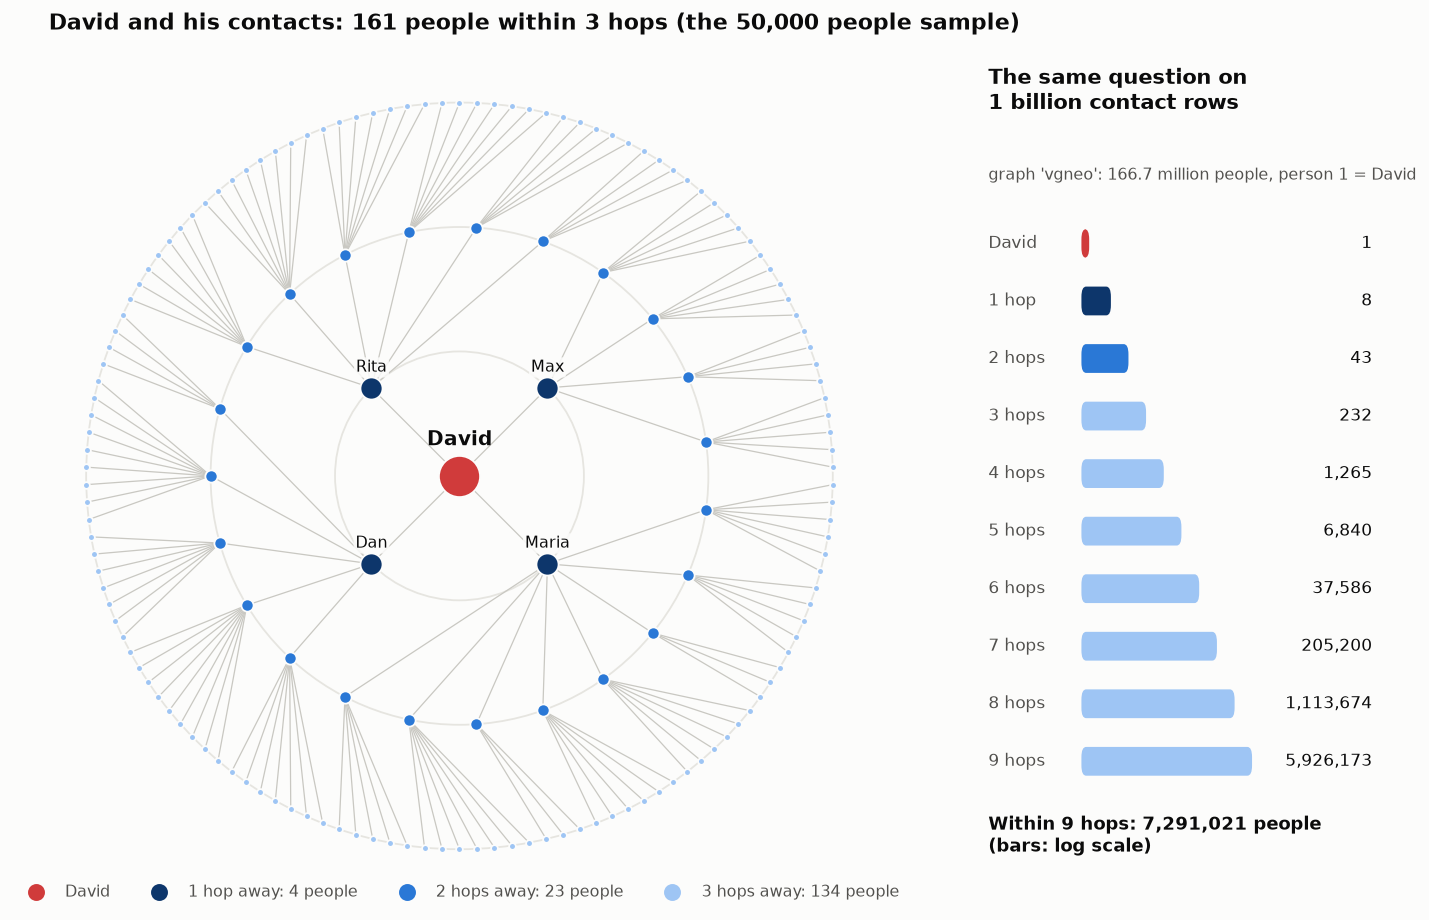

In [5]:
DAVID = 1
COLS = "start, target, src, dst, del, weight, ver, snapshot_id"
REST = "NULL::INT, NULL::INT, NULL::INT, NULL::BOOLEAN, NULL::FLOAT, NULL::INT, NULL::INT"
hood = q(f'''SELECT node, hops FROM (SELECT vgraph.gkhop({COLS} USING PARAMETERS graph='nb', start={DAVID}, depth=3) OVER()
             FROM VGRAPH_NB.nb_delta) r ORDER BY hops, node''')
print(f"{len(hood) - 1} people within 3 hops of David, answered in {q.ms} ms (server time)")

# The billion-row graph on this server. The generator picks random contacts, so every billion-row
# graph is a different graph: person 1 reaches a different number of people in each. The name and the
# size are printed with every result below, so no two runs can be mixed up.
BIG = q("SELECT graph, node_count, edge_count FROM vgraph.manifest WHERE active_snapshot IS NOT NULL AND edge_count > 500000000 ORDER BY edge_count DESC LIMIT 1")
have_big = len(BIG) > 0
BIG_LEVELS = [1, 4, 23, 117, 629, 3445, 18855, 102282, 556366, 2995783]      # a measured example
if have_big:
    BIG_NAME, BIG_NODES, BIG_EDGES = BIG.graph[0], int(BIG.node_count[0]), int(BIG.edge_count[0])
    BIG_LEVELS = list(q(f"SELECT hops, nodes FROM (SELECT vgraph.gkhop_count({DAVID}, {REST} USING PARAMETERS graph='{BIG_NAME}', depth=9) OVER() FROM dual) r ORDER BY hops").nodes)
    print(f"live billion-row graph on this server: '{BIG_NAME}', {BIG_NODES:,} people, {BIG_EDGES:,} contact rows")

def draw_david(hood, extra_edges=(), title="David and his contacts"):
    ids = ",".join(str(i) for i in hood.node)
    e = q(f"SELECT src_id, dst_id FROM VGRAPH_NB.contact WHERE src_id IN ({ids}) AND dst_id IN ({ids}) GROUP BY 1, 2 HAVING NOT MAX(del)")
    hops = dict(zip(hood.node, hood.hops))
    parent = {}
    for a, b in zip(e.src_id, e.dst_id):                     # the contact through which a person was reached first
        if hops[b] == hops[a] + 1 and (b not in parent or a < parent[b]): parent[b] = a
    angle = {DAVID: 0.0}; pos = {DAVID: (0, 0)}
    for h in (1, 2, 3):                                     # one ring per hop, children next to their parent
        ring = sorted((n for n in hops if hops[n] == h), key=lambda n: (angle[parent[n]], n))
        for k, n in enumerate(ring):
            angle[n] = 2 * math.pi * (k + 0.5) / len(ring)
            pos[n] = (h * math.cos(angle[n]), h * math.sin(angle[n]))
    fig, (ax, side) = plt.subplots(1, 2, figsize=(12, 7.2), gridspec_kw={"width_ratios": [2.3, 1]})
    ax.grid(False); ax.set_axis_off(); ax.set_aspect("equal"); side.grid(False); side.set_axis_off()
    for h in (1, 2, 3): ax.add_patch(plt.Circle((0, 0), h, fill=False, ec=GRID, lw=1))
    for n, p in parent.items(): ax.plot(*zip(pos[p], pos[n]), color="#c9c8c2", lw=0.7, zorder=1)
    for a, b in extra_edges: ax.plot(*zip(pos[a], pos[b]), color=ORANGE, lw=2.6, zorder=2)
    size = [520, 150, 46, 14]
    for h in (3, 2, 1, 0):
        ring = [n for n in hops if hops[n] == h]
        ax.scatter([pos[n][0] for n in ring], [pos[n][1] for n in ring], s=size[h], color=RINGS[h], edgecolors=SURFACE, linewidths=1.0, zorder=3)
    names = ["Max", "Rita", "Dan", "Maria", "Tom", "Lena", "Omar", "Julia", "Noah", "Maya", "Eva", "Anna"]
    ax.annotate("David", (0, 0), xytext=(0, 17), textcoords="offset points", ha="center", fontsize=11, fontweight="bold", color=INK)
    for name, n in zip(names, [n for n in hops if hops[n] == 1]):
        ax.annotate(name, pos[n], xytext=(0, 9), textcoords="offset points", ha="center", fontsize=9, color=INK,
                    bbox=dict(boxstyle="round,pad=0.12", fc=SURFACE, ec="none", alpha=0.85))
    for h in (0, 1, 2, 3):
        count = sum(1 for n in hops if hops[n] == h)
        ax.scatter([], [], s=70, color=RINGS[h], label="David" if h == 0 else f"{h} hop{'s' if h > 1 else ''} away: {count} people")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.02), ncol=4, frameon=False, labelcolor=INK2, fontsize=9)
    ax.set_xlim(-3.3, 3.3); ax.set_ylim(-3.3, 3.5); ax.set_title(title)
    # the side panel: the same question on one billion rows
    side.text(0, 0.97, "The same question on\n1 billion contact rows", fontsize=11.5, fontweight="bold", color=INK, va="top", transform=side.transAxes)
    side.text(0, 0.85, (f"graph '{BIG_NAME}': {BIG_NODES / 1e6:.1f} million people" if have_big else "166.7 million people") + ", person 1 = David",
              fontsize=9, color=INK2, va="top", transform=side.transAxes)
    top = math.log10(max(BIG_LEVELS))
    for h, v in enumerate(BIG_LEVELS):
        y = 0.76 - h * 0.068
        side.text(0.0, y, "David" if h == 0 else f"{h} hop{'s' if h > 1 else ''}", fontsize=9.5, color=INK2, va="center", transform=side.transAxes)
        side.add_patch(mpl.patches.FancyBboxPatch((0.24, y - 0.017), 0.02 + 0.42 * math.log10(max(v, 1)) / top, 0.034,
                       boxstyle="round,pad=0,rounding_size=0.012", fc=RINGS[min(h, 3)], ec="none", transform=side.transAxes))
        side.text(0.99, y, f"{v:,}", fontsize=9.5, color=INK, va="center", ha="right", transform=side.transAxes)
    side.text(0, 0.06, f"Within 9 hops: {sum(BIG_LEVELS) - 1:,} people\n(bars: log scale)", fontsize=10, fontweight="bold", color=INK, va="center", transform=side.transAxes)
    plt.tight_layout(); plt.show()

draw_david(hood, title=f"David and his contacts: {len(hood) - 1} people within 3 hops (the 50,000 people sample)")

## 5. The files involved in the tests

| File | What it does | How to use it |
|---|---|---|
| `../vertica-graphs-and-trees/graph_contacts_demo.sql` | the first repository: generates the contact table and holds the SQL procedure `bfs`, the correctness reference | cloned next to this repository; the scripts call it |
| `Makefile` | builds the library, runs the unit tests, installs it | `make && make test && make deploy` (`FENCED=no` for the fastest mode) |
| `src/engine/` | the graph engine, plain C++17: index, search, path, components, PageRank | compiled by `make` |
| `src/udx/` | one small Vertica adapter per SQL function | compiled by `make` |
| `sql/install.sql`, `sql/procedures.sql` | schema `vgraph`, the functions, the procedures `register_graph`, `refresh_graph`, ... | run by `make deploy` |
| `scripts/demo.sh` | a small end-to-end demo that cleans up after itself | `scripts/demo.sh` |
| `scripts/benchmark.sh` | the Vertica measurements: load, build, k-hop against the SQL procedure, fenced and unfenced | `scripts/benchmark.sh --rows=100000000` |
| `scripts/neo4j_compare.sh` | the side-by-side test: same data and questions in Vertica and Neo4j, answers compared | `scripts/neo4j_compare.sh --neo4j_home=DIR --rows=100000000` |
| `scripts/register.sh`, `scripts/refresh.sh` | register your own table as a graph; rebuild, schedule, check | see the README |
| `tests/` | unit tests of the engine, integration tests against the SQL procedure | `make test`, `tests/sql/*.sh` |
| `notebook/vgraph_demo.ipynb` | this notebook | Jupyter |

## 6. The functions, live

Four questions on the sample, each one SQL statement. `nb_delta` is the view that `register_graph` created: it
hands the function the rows written after the index was built, so answers are exact on live data.

**Within k hops: `gkhop_count`** returns one row per distance (`gkhop` returns the people themselves).

In [6]:
levels = q(f'''SELECT hops, nodes AS people FROM (SELECT vgraph.gkhop_count({COLS} USING PARAMETERS graph='nb', start={DAVID}, depth=6) OVER()
               FROM VGRAPH_NB.nb_delta) r ORDER BY hops''')
print(f"answered in {q.ms} ms (server time)")
levels.T

answered in 5 ms (server time)


,0,1,2,3,4,5,6
hops,0,1,2,3,4,5,6
people,1,4,23,134,697,3617,15246


**Shortest path: `gpath`.** How is David connected to the person with the highest id?

In [7]:
path = q(f'''SELECT hop_no, node AS person FROM (SELECT vgraph.gpath({COLS} USING PARAMETERS graph='nb', start={DAVID}, target={PEOPLE}) OVER()
             FROM VGRAPH_NB.nb_delta) p ORDER BY hop_no''')
print(f"{len(path) - 1} hops, answered in {q.ms} ms (server time)")
path.T

5 hops, answered in 3 ms (server time)


,0,1,2,3,4,5
hop_no,0,1,2,3,4,5
person,1,16736,49032,23786,43848,50000


**Connected components: `gcomponents_count`**, and **PageRank: `gpagerank`** with `top=5`.

In [8]:
comp = q(f'''SELECT component, nodes AS people FROM (SELECT vgraph.gcomponents_count({COLS} USING PARAMETERS graph='nb') OVER()
             FROM VGRAPH_NB.nb_delta) c ORDER BY nodes DESC LIMIT 3''')
print(f"components: answered in {q.ms} ms (server time)"); print(comp.to_string(index=False))
rank = q(f'''SELECT node AS person, rank FROM (SELECT vgraph.gpagerank({COLS} USING PARAMETERS graph='nb', iterations=20, top=5) OVER()
             FROM VGRAPH_NB.nb_delta) r ORDER BY rank DESC''')
print(f"\nPageRank over all {PEOPLE:,} people: answered in {q.ms} ms (server time)"); print(rank.to_string(index=False))

components: answered in 4 ms (server time)
 component  people
         1   50000



PageRank over all 50,000 people: answered in 8 ms (server time)
 person     rank
  41547 0.000046
  26326 0.000045
  21357 0.000045
  24890 0.000043
   3885 0.000043


**Live data.** David meets a new person, number 50,001: one `INSERT` (both directions). Nothing is rebuilt. The
same question sees the change at once, because every query reads the index plus the rows written after it.

In [9]:
before = len(hood) - 1
NEW = PEOPLE + 1
run(f"INSERT INTO VGRAPH_NB.contact (src_id, dst_id) VALUES ({DAVID}, {NEW});\nINSERT INTO VGRAPH_NB.contact (src_id, dst_id) VALUES ({NEW}, {DAVID});\nCOMMIT")
after = q(f'''SELECT COUNT(*) - 1 AS n FROM (SELECT vgraph.gkhop({COLS} USING PARAMETERS graph='nb', start={DAVID}, depth=3) OVER()
              FROM VGRAPH_NB.nb_delta) r''').n[0]
print(f"within 3 hops of David: {before} people before, {after} now, without a refresh ({q.ms} ms)")

within 3 hops of David: 161 people before, 162 now, without a refresh (3 ms)


## 7. Results: 100 million rows, Neo4j and Vertica side by side

100 million contact rows, 16.7 million people, the machine of section 3. Both systems returned the same answer
for every question. Measured on the server with `scripts/neo4j_compare.sh`; this notebook draws the numbers.

| Question (100 million rows) | Neo4j | Vertica + vgraph | Vertica is |
|---|---:|---:|---|
| people within 2 hops of David (28) | 1 to 2 ms | 2 ms | equal * |
| people within 3 hops (144) | 1 to 3 ms | 2 ms | equal * |
| people within 6 hops (22,553) | 10 ms | **3 ms** | **3 times faster** |
| people within 9 hops (3.3 million) | 2.28 s | **0.046 s** | **50 times faster** |
| shortest path, 12 hops | 15 ms | **4 ms** | **3.8 times faster** |
| connected components | 0.67 s, after a 5.8 s projection | **0.37 s** | **1.8 times faster** |
| PageRank, 20 iterations | 18.1 s, after the same projection | **1.54 s** | **12 times faster** |
| load the data | 45 s (export, import, index) | 17 s | |
| prepare for graph queries | 5.8 s projection, after every restart | 19 s index build (`refresh_graph`) | |
| size on disk | 2.8 GB | **1.1 GB** (table 444 MB + index 667 MB) | **2.5 times smaller** |

\* **At or below the cost of `SELECT 1;`** (up to 2 ms on this machine). These times measure the cost of a
statement, not of a graph search. They are not relevant for the comparison and are shown for completeness.

Neo4j: the better of a Cypher pattern and APOC for the k-hop questions; Graph Data Science for components and
PageRank (community edition: at most 4 threads). At 6 hops Vertica's 3 ms is itself the cost of a
statement, so read "3 times" as "at least".

**What the 100 million row test says.** Where the question is large enough to measure the engine, Vertica is
faster: 3 times at 6 hops, 50 times at 9 hops, 3.8 times for the shortest path, 12 times for PageRank and 1.8
times for components. It also needs 2.5 times less disk space. It did not start that way: the first run lost
the shortest path by a factor of 100, and a search from both ends fixed it.

**This table was measured again on 2026-09-21**, on newly generated data loaded into both systems (the
generator is random: in this graph person 1 reaches 3.3 million people within 9 hops, in the run published
before 5.8 million). The reason for the new run is in section 8.

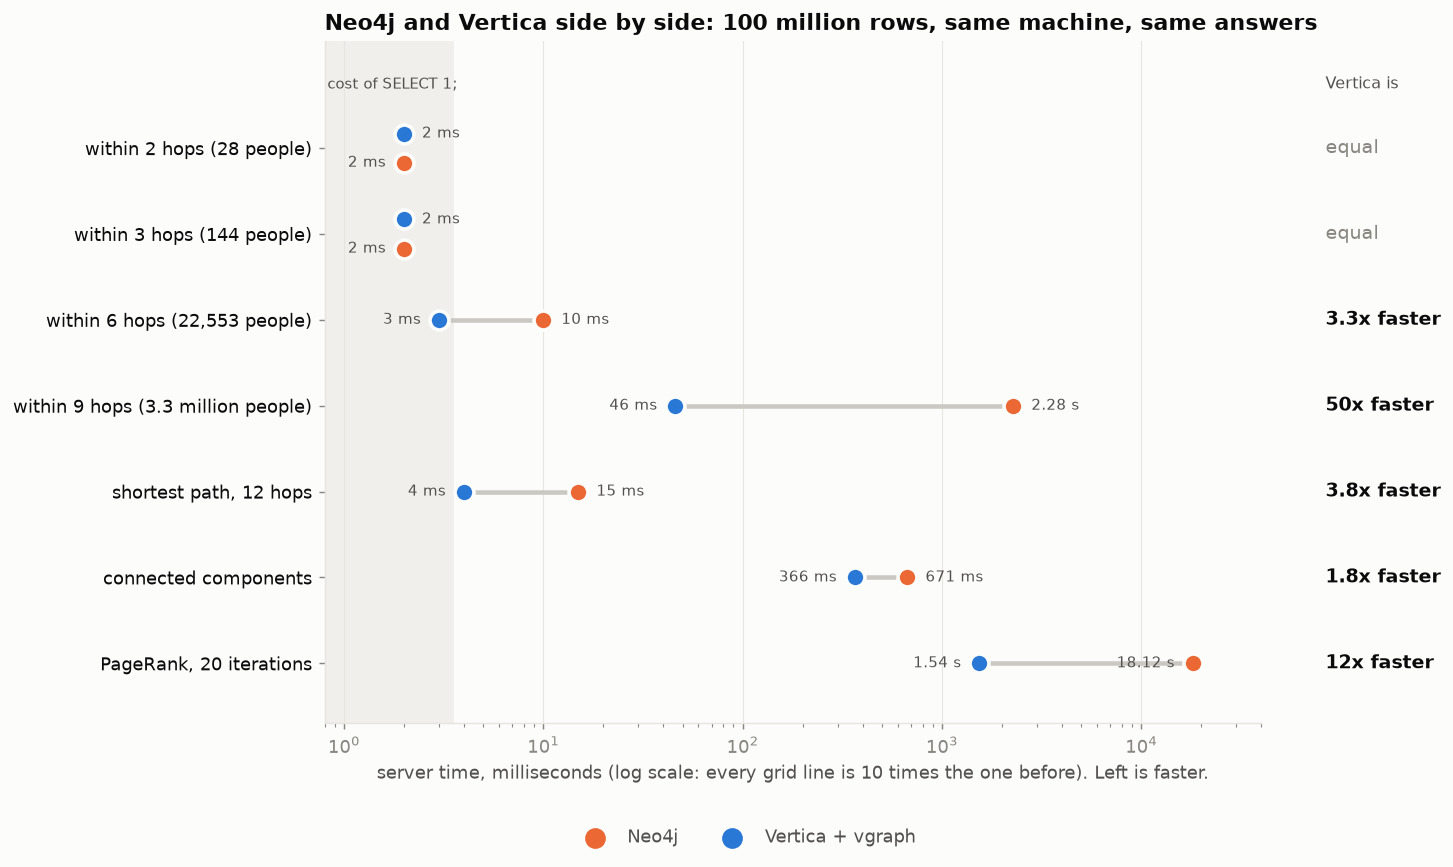

In [10]:
# Milliseconds, measured on the server by scripts/neo4j_compare.sh. Edit with the numbers of your own run.
# A Neo4j time of None means the question did not finish (the reason is in the text).
SELECT1 = 3          # ms: at or below this, a time is the cost of a statement, not of a graph search

M100 = [   # question, Neo4j, Vertica
    ("within 2 hops (28 people)",          2,     2),
    ("within 3 hops (144 people)",         2,     2),
    ("within 6 hops (22,553 people)",      10,    3),
    ("within 9 hops (3.3 million people)", 2280,  46),
    ("shortest path, 12 hops",             15,    4),
    ("connected components",               671,   366),
    ("PageRank, 20 iterations",            18120, 1540),
]

def verdict(neo, ver):
    if neo is None: return "Neo4j did not finish"
    if max(neo, ver) <= SELECT1 or abs(neo - ver) <= 1: return "equal"
    f = neo / ver
    if f < 1: return f"Neo4j {1 / f:.1f}x faster"
    return f"{f:.0f}x faster" if f >= 10 else f"{f:.1f}x faster"

def ms(v): return human(v) if v < 1000 else f"{v / 1000:.2f} s"

def side_by_side(rows, title, xmax=40000):
    # one row per question: the Neo4j dot and the Vertica dot on a log time axis, left is faster
    fig, ax = plt.subplots(figsize=(11, 0.66 * len(rows) + 2.2))
    rows = rows[::-1]
    ax.axvspan(0.8, SELECT1 * 1.18, color="#f0efec", zorder=0)
    ax.text(1.75, len(rows) - 0.35, "cost of SELECT 1;", ha="center", va="bottom", fontsize=8.5, color=INK2)
    for y, (name, neo, ver) in enumerate(rows):
        if neo is not None:
            ax.plot([neo, ver], [y, y], color="#c9c8c2", lw=2.5, zorder=1, solid_capstyle="round")
            tie = abs(math.log10(neo) - math.log10(ver)) < 0.12
            pair = ((neo, ORANGE, -0.17 if tie else 0), (ver, BLUE, 0.17 if tie else 0))
        else:
            tie, pair = False, ((ver, BLUE, 0),)
        for val, c, dy in pair:
            ax.scatter(val, y + dy, s=110, color=c, edgecolors=SURFACE, linewidths=2, zorder=3)
            left = (c == ORANGE) if tie else (val == min(neo, ver) if neo is not None else False)
            if val > xmax / 4: left = True                    # near the right edge, label inwards
            ax.annotate(ms(val), (val, y + dy), xytext=(-10 if left else 10, 0), textcoords="offset points",
                        ha="right" if left else "left", va="center", fontsize=8.5, color=INK2)
        v = verdict(neo, ver)
        ax.text(xmax * 2.1, y, v, va="center", ha="left", fontsize=10.5, color=INK if "faster" in v else MUTED,
                fontweight="bold" if v.endswith("faster") and not v.startswith("Neo4j ") else "normal")
    ax.text(xmax * 2.1, len(rows) - 0.35, "Vertica is", fontsize=9, color=INK2, va="bottom")
    ax.set_yticks(range(len(rows))); ax.set_yticklabels([r[0] for r in rows], color=INK)
    ax.set_ylim(-0.7, len(rows) + 0.25)
    ax.set_xscale("log"); ax.set_xlim(0.8, xmax); ax.grid(axis="y", visible=False)
    ax.set_xlabel("server time, milliseconds (log scale: every grid line is 10 times the one before). Left is faster.")
    ax.scatter([], [], s=110, color=ORANGE, label="Neo4j"); ax.scatter([], [], s=110, color=BLUE, label="Vertica + vgraph")
    ax.legend(frameon=False, labelcolor=INK2, loc="upper center", bbox_to_anchor=(0.45, -0.13), ncol=2)
    ax.set_title(title)
    plt.subplots_adjust(right=0.78); plt.show()

B1 = [   # 1 billion rows, 2026-09-21. Each system alone on the machine, warm cache, best of several.
         # Vertica measured again the same day, after the index mapping was kept between statements.
    ("within 2 hops (52 people)",             2,      3),
    ("within 3 hops (284 people)",            2,      3),
    ("within 6 hops (45,975 people)",         24,     4),
    ("within 9 hops (7.3 million people)",    5250,   76),
    ("shortest path, 13 hops",                33,     7),
    ("connected components",                  10850,  3599),
    ("PageRank, 20 iterations",               204290, 15504),
]

side_by_side(M100, "Neo4j and Vertica side by side: 100 million rows, same machine, same answers")

## 8. Results: one billion rows

The same generator with **1,000,000,000 rows**: 166.7 million people, on the same machine, and this time
**Neo4j was loaded with the same billion rows too**. The generator picks random contacts on every run, so this
is a different graph from the one in section 7: here person 1 reaches 7,291,022 people within 9 hops.

**How both systems were measured.** Neo4j's store for this graph is **26 GB** on a machine with 34 GB, so the
two systems cannot both be resident at once. Each was therefore measured **alone on the machine, with a warm
cache**: one run to warm it, then the best of the runs that followed. Both returned the same answer to every
question they could answer.

| Question (1 billion rows, 166.7 million people) | Neo4j | Vertica + vgraph | Vertica is |
|---|---:|---:|---|
| people within 2 hops of David (52) | 2 ms | 3 ms | equal * |
| people within 3 hops (284) | 2 ms | 3 ms | equal * |
| people within 6 hops (45,975) | 24 ms | **4 ms** | **6 times faster** |
| people within 9 hops (7,291,022) | 5.25 s | **0.076 s** | **69 times faster** |
| shortest path, 13 hops | 33 ms | **7 ms** | **4.7 times faster** |
| connected components (1) | 10.9 s, after a 169.5 s projection | **3.60 s** | **3 times** (50 with the projection) |
| PageRank, 20 iterations | 204.3 s, after the same projection | **15.5 s** | **13 times** (24 with the projection) |
| get the data in | 9.7 min (export 1.9 + import 6.3 + index 1.4) | **2.2 min** (generated in place) | 4.3 times |
| prepare for graph queries | **169.5 s** projection, again after every restart | 10.2 min `refresh_graph`, once per refresh | Neo4j 3.6 times |
| size on disk | 26.4 GB | **11.6 GB** (table 4.9 + index 6.7) | **2.3 times smaller** |

\* At or below the cost of `SELECT 1;`: not relevant for the comparison.

**These numbers were measured twice, and the first ones are worth knowing.** The first publication of this
table had 31 ms at 6 hops, 0.19 s at 9 hops and 116 ms for the shortest path, and Neo4j won the path row by 3.5
times. Looking for the reason showed that the search was not the cost. Every statement mapped the 6.7 GB index
file anew, and a new mapping pays a page fault for every page a search touches: 34,000 faults for that one
path, 50 ms of faults around an 8 ms search. The library now keeps the mapping between statements. `gpath` also
got a `threads` parameter and stops at the first meeting of its two searches. Neo4j's numbers are the ones
measured before: nothing changed on its side. Again it was the competitor on the same machine that found the
problem.

**The memory finding.** No single Neo4j configuration on this machine could answer all the questions:

- The k-hop questions need a large **page cache**. With 10 GB of page cache, 9 hops took **242.9 s**. With
  22 GB, the same question took **5.25 s**: 46 times faster, same software, same data.
- The whole-graph algorithms need a large **heap**. With a 14 GB heap, `gds.graph.project` stopped with
  `java.lang.OutOfMemoryError`. It needed a **26 GB heap**, and then took 169.5 s to build its in-memory copy
  of the graph before any algorithm could run.
- A 22 GB page cache and a 26 GB heap do not both fit in 34 GB.

Vertica needed no such choice. Its index for the same graph is 6.7 GB, so the operating system keeps it cached,
and one configuration answers every question. That is the practical value of the compact index, and it is worth
more than any single number in the table.

**What the one billion row test says.** Vertica is far ahead on the deep question (69 times), ahead at 6 hops
(6 times) and on the shortest path (4.7 times), on the whole-graph algorithms (3 and 13 times, before counting
the projection Neo4j must build first), on disk and on loading. Neo4j is ahead in preparing for the whole-graph
algorithms (a 170 s projection against a 10 minute index build), and the smallest questions are the cost of a
statement on both sides. Ten times more data than section 7 did not change the
shape of the answer: the search follows the answer, not the table.

The next cells ask this server's own billion-row graph live. Only a dozen result rows travel to the notebook,
and the time shown is the server's own measurement.

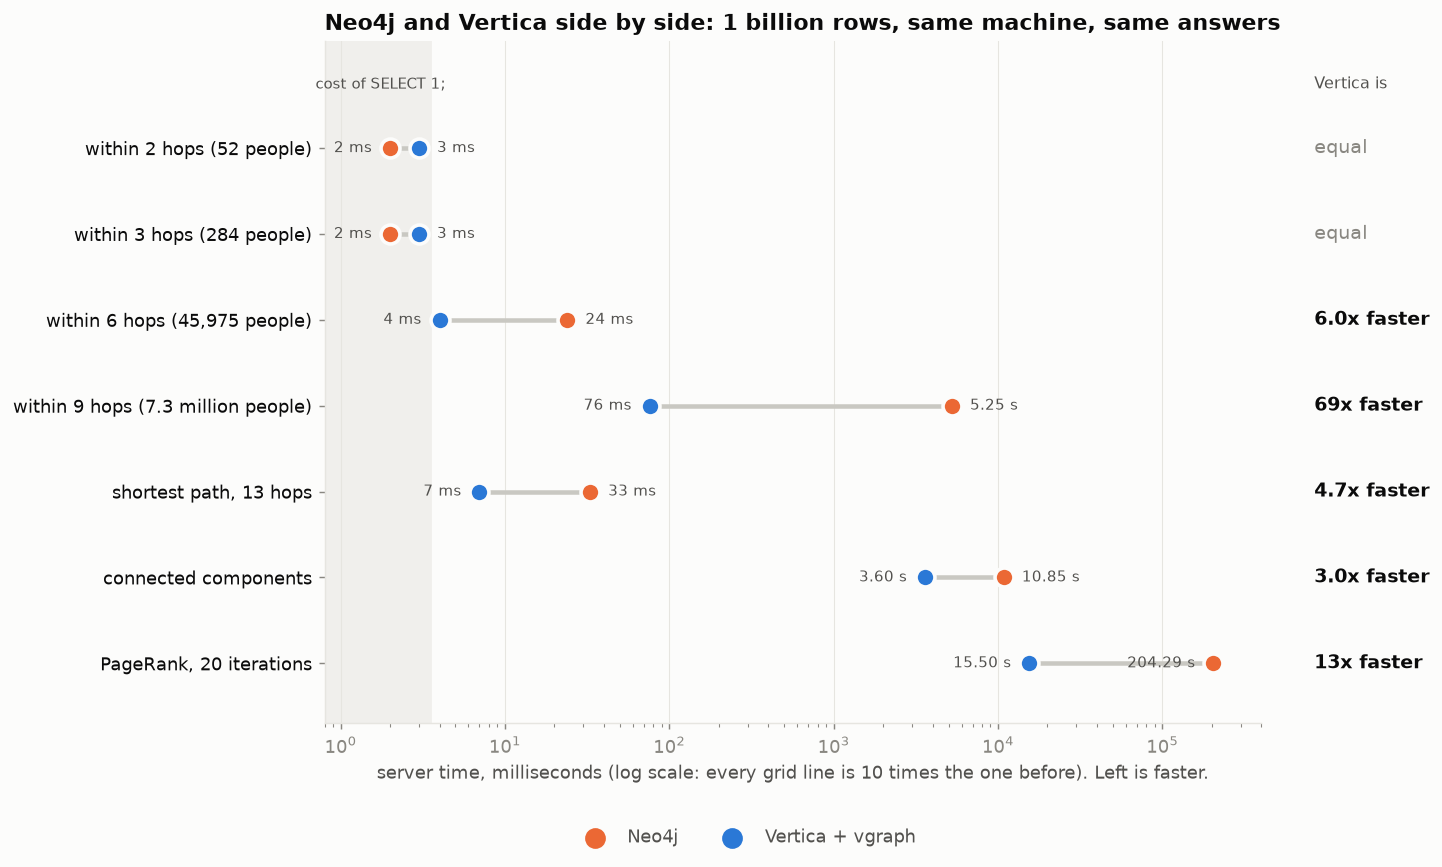

In [11]:
side_by_side(B1, f"Neo4j and Vertica side by side: 1 billion rows, same machine, same answers", xmax=400000)

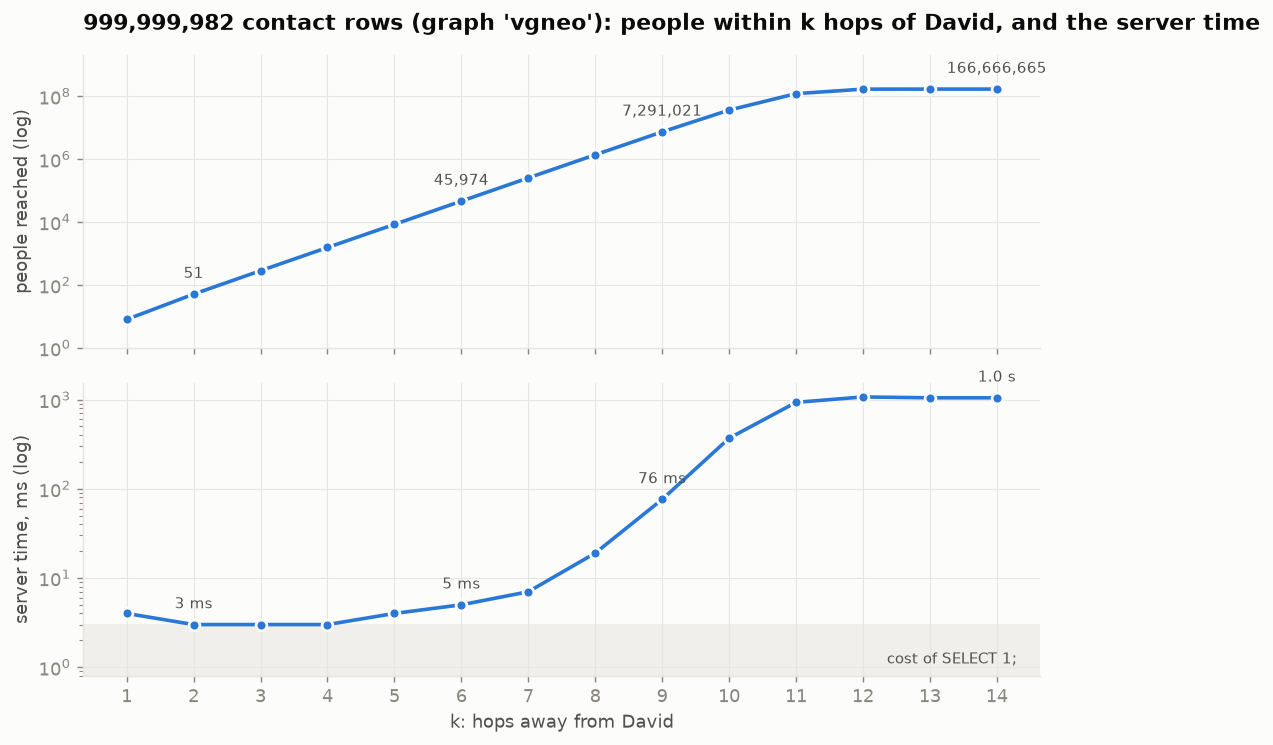

In [12]:
if not have_big:
    print("no billion-row graph is registered here: skipped")
else:
    def count_big(depth, threads=None):
        extra = f", threads={threads}" if threads else ""
        best = None
        for _ in range(2):                      # best of two
            r = q(f"SELECT hops, nodes FROM (SELECT vgraph.gkhop_count({DAVID}, {REST} USING PARAMETERS graph='{BIG_NAME}', depth={depth}{extra}) OVER() FROM dual) r ORDER BY hops")
            best = q.ms if best is None else min(best, q.ms)
        return r, best
    sweep = []
    for d in range(1, 15):
        r, ms = count_big(d)
        sweep.append({"depth": d, "people": int(r.nodes.sum()) - 1, "ms": max(int(ms), 1)})
    sweep = pd.DataFrame(sweep)
    fig, (top, bottom) = plt.subplots(2, 1, figsize=(9.5, 6.2), sharex=True, gridspec_kw={"hspace": 0.12})
    top.plot(sweep.depth, sweep.people, color=BLUE, lw=2, marker="o", ms=6, mec=SURFACE, mew=1.5)
    top.set_yscale("log"); top.set_ylabel("people reached (log)")
    top.set_title(f"{BIG_EDGES:,} contact rows (graph '{BIG_NAME}'): people within k hops of David, and the server time", pad=14)
    top.set_ylim(1, sweep.people.max() * 12)
    bottom.plot(sweep.depth, sweep.ms, color=BLUE, lw=2, marker="o", ms=6, mec=SURFACE, mew=1.5)
    bottom.axhspan(0.8, SELECT1, color="#f0efec", zorder=0); bottom.text(14.3, 1.1, "cost of SELECT 1;", ha="right", fontsize=8.5, color=INK2)
    bottom.set_yscale("log"); bottom.set_ylim(0.8, None); bottom.set_ylabel("server time, ms (log)"); bottom.set_xlabel("k: hops away from David")
    for d in (2, 6, 9, 14):
        row = sweep[sweep.depth == d].iloc[0]
        top.annotate(f"{row.people:,}", (d, row.people), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=8.5, color=INK2)
        bottom.annotate(human(row.ms), (d, row.ms), xytext=(0, 9), textcoords="offset points", ha="center", fontsize=8.5, color=INK2)
    bottom.set_xticks(sweep.depth); plt.show()

## 9. Bottom line

- **One question started it:** *"Can Vertica give me level 9 of David's contacts, the way Neo4j does?"*
  Yes. On one billion rows, in **0.08 s**, next to Neo4j's 5.25 s on the same data and the same machine.
- **Where Vertica wins:** deep traversals (**69 times** at 9 hops on a billion rows, **50 times** at 100
  million), the shortest path (**4.7** and **3.8 times**), the whole-graph algorithms (**3 times** for components and **13 times** for PageRank, before
  counting the 169 s projection Neo4j has to build first), disk (**2.5 times less** at 100 million, **less than half**
  at a billion) and loading.
- **Where Neo4j wins:** preparing for the whole-graph algorithms (its projection takes 170 s at a billion
  rows, the Vertica index build 10 minutes; but the projection is built again after every restart and the index
  is not). Small neighbourhoods are the cost of a statement on both sides.
- **What the first publication got wrong:** it showed Neo4j 3.5 times faster at the shortest path on a billion
  rows. The search was never slow; every statement paid for mapping the index file anew. Section 8 tells it.
- **The finding that matters most is not a ratio.** Neo4j's store for the billion-row graph is 26 GB on a 34 GB
  machine, and no single configuration could answer everything: the traversals need a large page cache (9 hops:
  242.9 s with 10 GB, 5.25 s with 22 GB), the algorithms need a large heap (they failed outright with 14 GB and
  needed 26 GB), and the two do not fit together. Vertica's index for the same graph is 6.7 GB, so one
  configuration answers every question.
- **No second system.** The contacts stay in a Vertica table. The result of a graph function is SQL rows that
  join with everything else in the warehouse, and answers are exact on live data.
- **A UDx makes it a built-in.** Once compiled and installed, anybody can call `vgraph.gkhop(...)` like any
  other Vertica function.
- **The limits, plainly.** This is graph *analytics*. It is not a Cypher engine and not a property-graph store.
  The results are for one data shape, on one machine, against Neo4j Community. For graph analytics on warehouse
  data, Vertica with this extension surpasses Neo4j's capabilities in these measurements.

Run it yourself: `scripts/neo4j_compare.sh` repeats the whole comparison on your hardware. Compare the answers
first and the times second. https://github.com/mogomo/vertica-graph-udx

### Clean up

    CALL vgraph.unregister_graph('nb');
    DROP SCHEMA VGRAPH_NB CASCADE;